In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()
dataset = datasets.FashionMNIST(
    root='./root',
    train=True,
    transform=transform,
    target_transform=None,
    download=True)
loader = DataLoader(
    dataset=dataset,
    batch_size=32,
    shuffle=True)

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.71MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 139kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.7MB/s]


In [3]:
class AutoEncoder(nn.Module):
  def __init__(self, dropout, input_dims, hidden_dims, output_dims):
    super().__init__()
    self.encode = nn.Sequential(
        nn.Linear(input_dims, hidden_dims),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_dims, hidden_dims//2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_dims//2, hidden_dims//4),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_dims//4, output_dims)
    )
    self.decode = nn.Sequential(
        nn.Linear(output_dims, hidden_dims//4),
        nn.ReLU(),
        nn.Linear(hidden_dims//4, hidden_dims//2),
        nn.ReLU(),
        nn.Linear(hidden_dims//2, hidden_dims),
        nn.ReLU(),
        nn.Linear(hidden_dims, input_dims),
        nn.Sigmoid()
    )
  def forward(self, x):
    encoded = self.encode(x)
    decoded = self.decode(encoded)
    return decoded

In [4]:
model = AutoEncoder(0.3, 28*28, 512, 9)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-8)
loss_fn = nn.MSELoss()

In [8]:
epochs = 15
losses = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(epochs):
  model.train()

  for inputs,targets in loader:
    inputs = inputs.view(-1, 28 * 28).to(device)
    running_loss = 0

    optimizer.zero_grad()
    reconstruct = model(inputs)
    loss = loss_fn(reconstruct,inputs)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

  losses.append(running_loss)
  print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.5f}")

Epoch 1/15, Loss: 0.02379
Epoch 2/15, Loss: 0.02069
Epoch 3/15, Loss: 0.01622
Epoch 4/15, Loss: 0.01921
Epoch 5/15, Loss: 0.01770
Epoch 6/15, Loss: 0.01839
Epoch 7/15, Loss: 0.01988
Epoch 8/15, Loss: 0.01871
Epoch 9/15, Loss: 0.01814
Epoch 10/15, Loss: 0.01774
Epoch 11/15, Loss: 0.01593
Epoch 12/15, Loss: 0.02004
Epoch 13/15, Loss: 0.02164
Epoch 14/15, Loss: 0.01653
Epoch 15/15, Loss: 0.01623


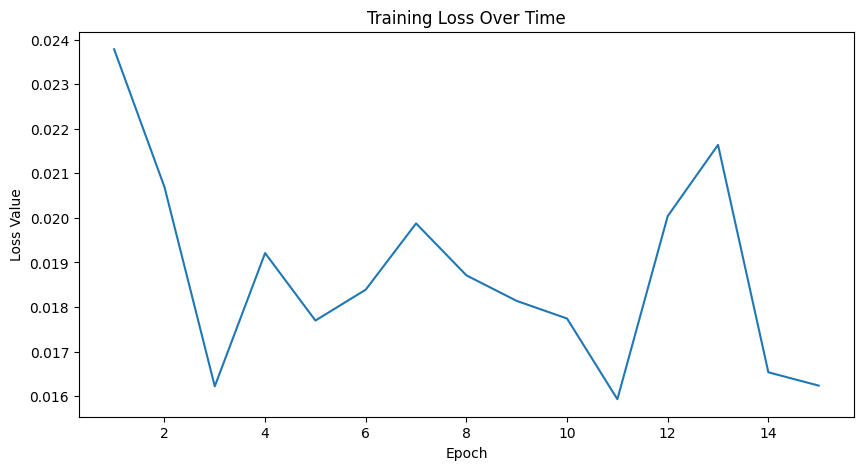

In [20]:
fig,ax = plt.subplots(figsize=(10,5))
ax.plot(range(1,len(losses)+1),losses)
ax.set_title("Training Loss Over Time")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss Value");

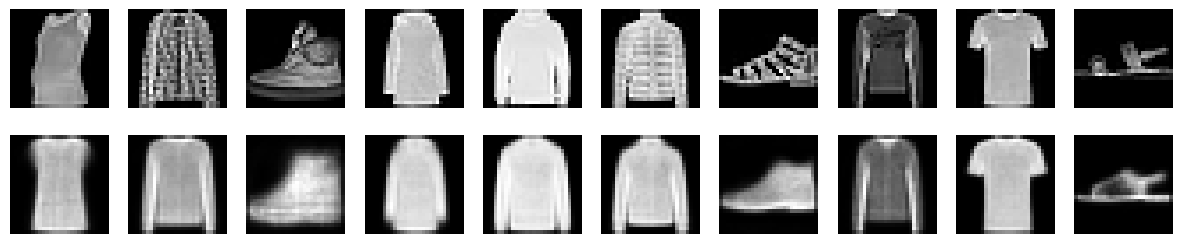

In [38]:
model.eval()
data_iterator = iter(loader)
images, _ = next(data_iterator)

images = images.view(-1, 28 * 28).to(device)
reconstructed = model(images)

fig,ax = plt.subplots(2,10, figsize=(15,3))
for i in range(10):
  ax[0,i].imshow(images[i].cpu().detach().numpy().reshape(28,28), cmap='gray')
  ax[0, i].axis('off')

  ax[1,i].imshow(reconstructed[i].cpu().detach().numpy().reshape(28,28), cmap='gray')
  ax[1, i].axis('off')